# SepAware Fixed-Lambda Study With 5-Fold Cross-Validation

This notebook is the cross-validated version of the earlier fixed-lambda SepAware notebooks.

It keeps the same logic:

1. Train CTGAN.
2. Generate a standard CTGAN dataset.
3. Generate a large candidate pool.
4. Score candidates by:

\[
S(x) = R(x) + \lambda_{sep} Sep(x) + \lambda_{anchor} A(x)
\]

5. Select full standalone synthetic datasets for:
   - the full lambda grid,
   - the varied-grid best configuration,
   - fixed lambda ablations.
6. Evaluate downstream utility.

The difference is that the experiment now uses **5-fold cross-validation**:

- CTGAN is trained separately inside each fold using only the real training fold.
- Candidate generation and SepAware selection happen inside each fold.
- Classifiers are trained on each fold's synthetic dataset and tested on the fold's held-out real data.
- Synthetic-only classifier performance is also evaluated with 5-fold CV within each synthetic dataset.

This notebook is **not** the `2^k r` factorial experiment. It is the old fixed-lambda workflow made fold-clean.

## 1. Setup

In [1]:
print('Using pinned dependencies from the local experiment environment.')

Using pinned dependencies from the local experiment environment.


## 2. Imports and Configuration

In [2]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance, t

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, silhouette_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

N_FOLDS = 5
CTGAN_EPOCHS = 100
CANDIDATE_POOL_MULTIPLIER = 5

LAMBDA_SEP_GRID = [0.0, 0.25, 0.5, 1.0]
LAMBDA_ANCHOR_GRID = [0.0, 0.25, 0.5]

FIXED_LAMBDA_CONFIGS = [
    ("Realism_only", 0.0, 0.0),
    ("Sep_low", 0.25, 0.0),
    ("Sep_medium", 0.5, 0.0),
    ("Sep_high", 1.0, 0.0),
    ("Anchor_low", 0.0, 0.25),
    ("Anchor_medium", 0.0, 0.5),
    ("Balanced_low", 0.25, 0.25),
    ("Balanced_medium", 0.5, 0.25),
    ("Balanced_high", 1.0, 0.5),
]

# Choose one or both.
RUN_DATASETS = ["covid", "vigitel"]

OUTPUT_DIR = Path("sepaware_fixed_lambda_5fold_cv_outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
PLOT_DIR = OUTPUT_DIR / "plots"
SYNTH_DIR = OUTPUT_DIR / "synthetic_folds"
for d in [TABLE_DIR, PLOT_DIR, SYNTH_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SAVE_SYNTHETIC_PER_FOLD = False

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: <SEPAWARE_DATA_ROOT>/sepaware_fixed_lambda_5fold_cv_outputs


## 3. Dataset Configuration

In [3]:
COVID_FEATURES = [
    "idade", "sexo", "etilismo", "tabagismo",
    "motivo_cancer", "motivo_msk", "motivo_digestivo2", "motivo_cardio2",
    "motivo_procedimentos2", "motivo_lesao2", "motivo_respiratorio", "motivo_neuro",
    "motivo_pele", "motivo_genitourinaria", "motivo_dm", "motivo_mental_subst",
    "motivo_infec2", "motivo_propedeutica",
    "n_comorbidades", "comorb_hipertensao", "comorb_ic", "comorb_dac",
    "comorb_fibrilacao", "comorb_avc", "comorb_dpoc", "comorb_asma",
    "comorb_dm", "comorb_obesidade", "comorb_drc", "comorb_cancer",
    "comorb_reumatologica", "comorb_cirrose", "comorb_hiv",
]

VIGITEL_FEATURES = [
    "age", "sex", "marital", "years_schooling", "Pregnancy", "family_allowance",
    "pesorake", "fumante", "exfuma", "mais20", "fumocasa", "fumotrab",
    "hortareg", "frutareg", "flvreg", "flvreco", "reco", "ati_livre",
    "ativo_livre", "inativo", "tv_d_3", "refri5", "suco5", "feijao5",
    "salada5", "crua5", "cozida5", "fruta5", "fruta_suco5", "leite",
    "gordura", "frango_pele", "carne_gordura", "doces5", "lanche_7",
    "diab", "hart", "has", "asma", "dislipidemia", "depressao",
]

DATASET_CONFIGS = {
    "covid": {
        "path_candidates": [Path("/content/banco_covidIH.xlsx"), Path("banco_covidIH.xlsx"), Path("<SEPAWARE_DATA_ROOT>/banco_covidIH.xlsx")],
        "file_type": "excel",
        "target": "obito",
        "target_candidates": ["obito"],
        "features": COVID_FEATURES,
        "anchors": ["idade", "sexo", "tabagismo", "comorb_cirrose"],
        "sample_n": None,
        "exclude": [],
        "output_prefix": "covid",
    },
    "vigitel": {
        "path_candidates": [Path("/content/vigitel2006_2023_obesidade_exclusoes.parquet"), Path("vigitel2006_2023_obesidade_exclusoes.parquet"), Path("<SEPAWARE_DATA_ROOT>/vigitel2006_2023_obesidade_exclusoes.parquet")],
        "file_type": "parquet",
        "target": "obesity",
        "target_candidates": ["obesity", "desfecho", "obesidade", "obeso"],
        "features": VIGITEL_FEATURES,
        "anchors": ["age", "sex", "fumante", "exfuma", "inativo", "ativo_livre", "ati_livre", "diab", "hart", "dislipidemia", "doces5", "lanche_7", "gordura", "flvreg", "years_schooling"],
        "sample_n": 5000,
        "exclude": ["chave"],
        "output_prefix": "vigitel",
    },
}

## 4. Load and Preprocess Data

In [4]:
def resolve_path(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"None of these paths exists: {candidates}")


def encode_sex_series(s):
    if pd.api.types.is_numeric_dtype(s):
        vals = pd.to_numeric(s, errors="coerce")
        uniq = set(vals.dropna().unique())
        if uniq.issubset({0, 1}):
            return vals
        if uniq.issubset({1, 2}):
            return vals.map({1: 0, 2: 1})
    mapping = {
        "f": 1, "fem": 1, "feminino": 1, "female": 1, "mulher": 1, "woman": 1,
        "m": 0, "masc": 0, "masculino": 0, "male": 0, "homem": 0, "man": 0,
        "0": 0, "1": 1, "2": 1,
    }
    cleaned = s.astype(str).str.strip().str.lower().str.normalize("NFKD").str.encode("ascii", errors="ignore").str.decode("ascii")
    return cleaned.map(mapping)


def clean_binary_like(s):
    vals = pd.to_numeric(s, errors="coerce")
    uniq = set(vals.dropna().unique())
    if uniq.issubset({0, 1}):
        return vals
    if uniq.issubset({1, 2}):
        return vals.map({1: 0, 2: 1})
    return vals


def normalize_binary_target(df, target, candidates):
    found = next((c for c in candidates if c in df.columns), None)
    if found is None:
        raise ValueError(f"No target found. Candidates={candidates}. Columns include: {list(df.columns)[:20]}")
    if found != target:
        df = df.rename(columns={found: target})
        print(f"Renamed target {found!r} to {target!r}")
    vals = pd.to_numeric(df[target], errors="coerce")
    df = df.loc[vals.notna()].copy()
    vals = vals.loc[vals.notna()]
    uniq = sorted(vals.unique())
    if set(uniq).issubset({0, 1}):
        df[target] = vals.astype(int)
    elif set(uniq).issubset({1, 2}):
        df[target] = vals.map({1: 0, 2: 1}).astype(int)
    elif len(uniq) == 2:
        df[target] = vals.map({uniq[0]: 0, uniq[1]: 1}).astype(int)
    else:
        raise ValueError(f"Target is not binary: {uniq[:20]}")
    return df


def stratified_sample(df, target, n):
    if n is None or len(df) <= n:
        return df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    parts = []
    props = df[target].value_counts(normalize=True)
    for cls, frac in props.items():
        k = int(round(n * frac))
        pool = df[df[target] == cls]
        parts.append(pool.sample(n=min(k, len(pool)), random_state=RANDOM_SEED))
    out = pd.concat(parts, ignore_index=True)
    if len(out) > n:
        out = out.sample(n=n, random_state=RANDOM_SEED)
    return out.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


def load_dataset(name, config):
    path = resolve_path(config["path_candidates"])
    print(f"Loading {name} from {path}")
    if config["file_type"] == "excel":
        df = pd.read_excel(path)
    elif config["file_type"] == "parquet":
        df = pd.read_parquet(path)
    else:
        raise ValueError(config["file_type"])
    df.columns = [str(c).strip() for c in df.columns]
    target = config["target"]
    df = normalize_binary_target(df, target, config["target_candidates"])
    df = stratified_sample(df, target, config.get("sample_n"))

    exclude = set(config.get("exclude", []))
    feature_candidates = [c for c in config["features"] if c in df.columns and c not in exclude and c != target]
    if not feature_candidates:
        feature_candidates = [c for c in df.columns if c not in exclude and c != target]
    missing = [c for c in config["features"] if c not in df.columns]
    if missing:
        print(f"{name}: skipped missing configured features:", missing[:20], "..." if len(missing) > 20 else "")

    raw = df[feature_candidates + [target]].copy()
    for sex_col in ["sexo", "sex"]:
        if sex_col in raw.columns:
            raw[sex_col] = encode_sex_series(raw[sex_col])
    for col in feature_candidates:
        raw[col] = pd.to_numeric(raw[col], errors="coerce")
        raw.loc[raw[col] == -1, col] = np.nan

    discrete_cols = []
    continuous_cols = []
    for col in feature_candidates:
        finite = raw[col].dropna()
        is_discrete = len(finite) == 0 or (finite.nunique() <= 12 and np.all(np.isclose(finite, np.round(finite))))
        if is_discrete:
            mode = raw[col].mode(dropna=True)
            raw[col] = raw[col].fillna(mode.iloc[0] if len(mode) else 0).round().astype(int)
            discrete_cols.append(col)
        else:
            raw[col] = raw[col].fillna(raw[col].median())
            continuous_cols.append(col)
    raw[target] = raw[target].astype(int)
    anchors = [a for a in config["anchors"] if a in feature_candidates]
    print(f"{name}: shape={raw.shape}, target_rate={raw[target].mean():.3f}, features={len(feature_candidates)}, anchors={anchors}")
    display(raw[target].value_counts().rename("count").to_frame())
    return raw.reset_index(drop=True), feature_candidates, discrete_cols, continuous_cols, anchors, target

## 5. Helper Functions

In [5]:
def normalize01(x):
    x = np.asarray(x, dtype=float)
    ok = np.isfinite(x)
    out = np.zeros_like(x, dtype=float)
    if ok.sum() == 0:
        return out
    lo, hi = np.nanpercentile(x[ok], [1, 99])
    out[ok] = 0.5 if hi <= lo else np.clip((x[ok] - lo) / (hi - lo), 0, 1)
    out[~ok] = np.nanmedian(out[ok]) if ok.any() else 0
    return out


def make_encoded_frame(df, features, discrete_cols, target, reference_df):
    out = pd.DataFrame(index=df.index)
    for col in features:
        x = pd.to_numeric(df[col], errors="coerce")
        ref = pd.to_numeric(reference_df[col], errors="coerce") if col in reference_df.columns else x
        if col in discrete_cols:
            mode = ref.mode(dropna=True)
            fill = mode.iloc[0] if len(mode) else 0
            out[col] = x.fillna(fill).round()
        else:
            out[col] = x.fillna(ref.median())
    out[target] = pd.to_numeric(df[target], errors="coerce").fillna(0).astype(int)
    return out


def scaled_matrix(df, features, discrete_cols, target, reference_df):
    enc = make_encoded_frame(df, features, discrete_cols, target, reference_df)
    ref = make_encoded_frame(reference_df, features, discrete_cols, target, reference_df)
    scaler = StandardScaler().fit(ref[features])
    return scaler.transform(enc[features])


def make_metadata(df, features, discrete_cols, target):
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(df)
    for col in df.columns:
        try:
            metadata.update_column(col, sdtype="categorical" if col == target or col in discrete_cols else "numerical")
        except Exception:
            pass
    return metadata


def clean_synthetic(syn, reference, features, discrete_cols, target):
    syn = syn[[x for x in features + [target] if x in syn.columns]].copy()
    for col in features:
        ref = pd.to_numeric(reference[col], errors="coerce")
        x = pd.to_numeric(syn[col], errors="coerce")
        if col in discrete_cols:
            allowed = sorted(ref.dropna().unique())
            mode = ref.mode(dropna=True)
            fill = mode.iloc[0] if len(mode) else 0
            x = x.fillna(fill).round()
            syn[col] = x.apply(lambda v: min(allowed, key=lambda a: abs(a - v)) if allowed else v).astype(int)
        else:
            syn[col] = x.fillna(ref.median()).clip(ref.quantile(0.001), ref.quantile(0.999))
    syn[target] = pd.to_numeric(syn[target], errors="coerce").fillna(reference[target].mode().iloc[0]).round().clip(0, 1).astype(int)
    return syn.reset_index(drop=True)


def train_ctgan(real_train, features, discrete_cols, target):
    metadata = make_metadata(real_train, features, discrete_cols, target)
    try:
        ctgan = CTGANSynthesizer(metadata, epochs=CTGAN_EPOCHS, verbose=False, cuda=False)
    except TypeError:
        ctgan = CTGANSynthesizer(metadata, epochs=CTGAN_EPOCHS, verbose=False)
    ctgan.fit(real_train)
    return ctgan


def sample_synth(ctgan, n, reference, features, discrete_cols, target, label):
    try:
        syn = ctgan.sample(num_rows=n)
    except TypeError:
        syn = ctgan.sample(n)
    syn = clean_synthetic(syn, reference, features, discrete_cols, target)
    print(f"{label}: shape={syn.shape}, target_rate={syn[target].mean():.3f}")
    return syn

In [6]:
def separability_metrics(df, dataset_name, features, discrete_cols, target, reference_df):
    enc = make_encoded_frame(df, features, discrete_cols, target, reference_df)
    X = scaled_matrix(enc, features, discrete_cols, target, reference_df)
    y = enc[target].to_numpy().astype(int)
    row = {"dataset": dataset_name, "n": len(enc)}
    if len(np.unique(y)) < 2 or len(y) < 3:
        row.update({"silhouette_cosine": np.nan, "SI_k1": np.nan, "HM_k1": np.nan})
        return row
    try:
        row["silhouette_cosine"] = silhouette_score(X, y, metric="cosine")
    except Exception:
        row["silhouette_cosine"] = np.nan
    nn = NearestNeighbors(n_neighbors=2).fit(X)
    near = nn.kneighbors(X, return_distance=False)[:, 1]
    row["SI_k1"] = float(np.mean(y[near] == y))
    d = cdist(X, X)
    np.fill_diagonal(d, np.inf)
    hm = []
    for i in range(len(y)):
        same = y == y[i]
        diff = y != y[i]
        same[i] = False
        if same.any() and diff.any():
            hm.append(np.min(d[i, diff]) - np.min(d[i, same]))
    row["HM_k1"] = float(np.mean(hm)) if hm else np.nan
    return row


def distribution_similarity(real_df, syn_df, features, discrete_cols):
    rows = []
    for col in features:
        r = pd.to_numeric(real_df[col], errors="coerce").dropna()
        s = pd.to_numeric(syn_df[col], errors="coerce").dropna()
        if len(r) == 0 or len(s) == 0:
            continue
        if col in discrete_cols:
            rv = r.value_counts(normalize=True)
            sv = s.value_counts(normalize=True)
            keys = set(rv.index).union(set(sv.index))
            diff = 0.5 * sum(abs(rv.get(k, 0) - sv.get(k, 0)) for k in keys)
            kind = "categorical_tvd"
        else:
            diff = wasserstein_distance(r, s) / max(r.max() - r.min(), 1e-9)
            kind = "numeric_wasserstein"
        rows.append({"feature": col, "kind": kind, "difference": float(diff), "similarity": float(1 - min(diff, 1))})
    return pd.DataFrame(rows)


def correlation_similarity(real_df, syn_df, features, target):
    cols = features + [target]
    r = real_df[cols].apply(pd.to_numeric, errors="coerce").corr(method="spearman").fillna(0)
    s = syn_df[cols].apply(pd.to_numeric, errors="coerce").corr(method="spearman").fillna(0).reindex(index=r.index, columns=r.columns).fillna(0)
    d = np.abs(r.values - s.values)
    upper = d[np.triu_indices_from(d, k=1)]
    return float(1 - np.clip(np.mean(upper) / 2, 0, 1))


def duplicate_memorization(real_df, syn_df, features, target):
    cols = features + [target]
    overlap = len(pd.merge(syn_df[cols], real_df[cols].drop_duplicates(), how="inner")) / max(1, len(syn_df))
    return {
        "duplicate_row_rate": float(syn_df.duplicated(subset=cols).mean()),
        "exact_real_overlap_rate": float(overlap),
    }


def quality_report(real_df, syn_df, dataset_name, features, discrete_cols, target):
    dist = distribution_similarity(real_df, syn_df, features, discrete_cols)
    cat = dist.loc[dist.kind == "categorical_tvd", "similarity"].mean() if not dist.empty else np.nan
    num = dist.loc[dist.kind == "numeric_wasserstein", "similarity"].mean() if not dist.empty else np.nan
    corr = correlation_similarity(real_df, syn_df, features, target)
    mem = duplicate_memorization(real_df, syn_df, features, target)
    score = float(np.nanmean([cat, num, corr, 1 - mem["duplicate_row_rate"], 1 - mem["exact_real_overlap_rate"]]))
    return {"dataset": dataset_name, "categorical_similarity": cat, "numeric_similarity": num, "correlation_similarity": corr, "quality_score": score, **mem}

In [7]:
def fit_selection_context(real_train, features, discrete_cols, continuous_cols, anchors, target):
    enc = make_encoded_frame(real_train, features, discrete_cols, target, real_train)
    X = scaled_matrix(enc, features, discrete_cols, target, real_train)
    y = enc[target].to_numpy().astype(int)
    ctx = {
        "enc": enc,
        "X": X,
        "y": y,
        "real_train": real_train,
        "nn_real": NearestNeighbors(n_neighbors=1).fit(X),
        "class_nn": {},
        "anchor_stats": {},
    }
    for cls in [0, 1]:
        if (y == cls).any():
            ctx["class_nn"][cls] = NearestNeighbors(n_neighbors=1).fit(X[y == cls])
    clf = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
    clf.fit(enc[features], y)
    ctx["clf"] = clf
    for a in anchors:
        if a in continuous_cols:
            ctx["anchor_stats"][a] = ("continuous", enc.groupby(target)[a].agg(["mean", "std"]).to_dict("index"))
        else:
            ctx["anchor_stats"][a] = ("discrete", enc.groupby(a)[target].mean().to_dict())
    return ctx


def score_candidates(pool, ctx, features, discrete_cols, target):
    enc = make_encoded_frame(pool, features, discrete_cols, target, ctx["real_train"])
    X = scaled_matrix(enc, features, discrete_cols, target, ctx["real_train"])
    y = enc[target].to_numpy().astype(int)
    realism = 1 - normalize01(ctx["nn_real"].kneighbors(X, return_distance=True)[0].ravel())
    same = np.full(len(enc), np.nan)
    opp = np.full(len(enc), np.nan)
    for cls in [0, 1]:
        idx = np.where(y == cls)[0]
        if len(idx) and cls in ctx["class_nn"]:
            same[idx] = ctx["class_nn"][cls].kneighbors(X[idx], return_distance=True)[0].ravel()
        if len(idx) and (1 - cls) in ctx["class_nn"]:
            opp[idx] = ctx["class_nn"][1 - cls].kneighbors(X[idx], return_distance=True)[0].ravel()
    p = ctx["clf"].predict_proba(enc[features])
    conf = np.array([p[i, int(y[i])] for i in range(len(y))])
    separability = 0.5 * normalize01(opp - same) + 0.5 * normalize01(conf)
    terms = []
    for a, (typ, stats) in ctx["anchor_stats"].items():
        vals = []
        for _, row in enc.iterrows():
            if typ == "continuous":
                st = stats.get(int(row[target]), {})
                mu = st.get("mean", np.nan)
                sd = st.get("std", np.nan)
                vals.append(np.exp(-abs(row[a] - mu) / sd) if np.isfinite(mu) and np.isfinite(sd) and sd > 0 else 0.5)
            else:
                prob = stats.get(row[a], np.nan)
                vals.append((prob if int(row[target]) == 1 else 1 - prob) if np.isfinite(prob) else 0.5)
        terms.append(np.asarray(vals))
    anchor = normalize01(np.mean(terms, axis=0)) if terms else np.full(len(enc), 0.5)
    scored = pool.copy().reset_index(drop=True)
    scored["realism_score"] = realism
    scored["separability_score"] = separability
    scored["anchor_preservation_score"] = anchor
    return scored


def select_by_score(scored, real_train, features, discrete_cols, target):
    desired = real_train[target].value_counts().to_dict()
    parts = []
    for cls in [0, 1]:
        n = int(desired.get(cls, 0))
        parts.append(scored[scored[target].astype(int) == cls].sort_values("final_score", ascending=False).head(n))
    out = pd.concat(parts, axis=0)
    if len(out) < len(real_train):
        out = pd.concat([out, scored.drop(index=out.index).sort_values("final_score", ascending=False).head(len(real_train) - len(out))])
    mean_selected_score = float(out["final_score"].mean())
    mean_realism = float(out["realism_score"].mean())
    mean_sep = float(out["separability_score"].mean())
    mean_anchor = float(out["anchor_preservation_score"].mean())
    drop_cols = [c for c in ["realism_score", "separability_score", "anchor_preservation_score", "final_score"] if c in out.columns]
    return clean_synthetic(out.drop(columns=drop_cols), real_train, features, discrete_cols, target), {
        "mean_selected_row_final_score": mean_selected_score,
        "mean_selected_realism_score": mean_realism,
        "mean_selected_separability_score": mean_sep,
        "mean_selected_anchor_score": mean_anchor,
    }


def make_selected_dataset(scored_pool, real_train, features, discrete_cols, target, lambda_sep, lambda_anchor):
    scored = scored_pool.copy()
    scored["final_score"] = scored["realism_score"] + lambda_sep * scored["separability_score"] + lambda_anchor * scored["anchor_preservation_score"]
    return select_by_score(scored, real_train, features, discrete_cols, target)

In [8]:
def model_specs():
    return {
        "CatBoost": CatBoostClassifier(
            iterations=300,
            depth=4,
            learning_rate=0.05,
            loss_function="Logloss",
            eval_metric="F1",
            random_seed=RANDOM_SEED,
            verbose=False,
            allow_writing_files=False,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_SEED,
            n_jobs=1,
        ),
    }


def split_xy(train_df, test_df, features, discrete_cols, target):
    train_enc = make_encoded_frame(train_df, features, discrete_cols, target, train_df)
    test_enc = make_encoded_frame(test_df, features, discrete_cols, target, train_df)
    X_train = train_enc[features]
    y_train = train_enc[target].astype(int)
    X_test = test_enc[features]
    y_test = test_enc[target].astype(int)
    imp = SimpleImputer(strategy="median")
    X_train = pd.DataFrame(imp.fit_transform(X_train), columns=features)
    X_test = pd.DataFrame(imp.transform(X_test), columns=features)
    return X_train, X_test, y_train, y_test


def pred_metrics(y_true, pred, score=None):
    out = {
        "Macro_F1": f1_score(y_true, pred, average="macro", zero_division=0),
        "Accuracy": accuracy_score(y_true, pred),
        "Precision_macro": precision_score(y_true, pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, pred, average="macro", zero_division=0),
    }
    if score is not None and len(np.unique(y_true)) == 2:
        try:
            out["ROC_AUC"] = roc_auc_score(y_true, score)
        except Exception:
            out["ROC_AUC"] = np.nan
    else:
        out["ROC_AUC"] = np.nan
    return out


def fit_eval(train_df, test_df, dataset_name, evaluation, fold, dataset_group, features, discrete_cols, target):
    Xtr, Xte, ytr, yte = split_xy(train_df, test_df, features, discrete_cols, target)
    rows = []
    for model_name, model in model_specs().items():
        try:
            model.fit(Xtr.to_numpy(), ytr.to_numpy())
            pred = np.asarray(model.predict(Xte.to_numpy())).ravel().astype(int)
            score = None
            if hasattr(model, "predict_proba"):
                proba = model.predict_proba(Xte.to_numpy())
                score = proba[:, 1] if proba.shape[1] > 1 else proba.ravel()
            rows.append({
                "dataset_group": dataset_group,
                "fold": fold,
                "evaluation": evaluation,
                "dataset": dataset_name,
                "classifier": model_name,
                **pred_metrics(yte, pred, score),
            })
        except Exception as e:
            print(f"{dataset_group} fold {fold} {dataset_name} {model_name} failed:", repr(e))
    return rows


def synthetic_internal_cv(df, dataset_name, outer_fold, dataset_group, features, discrete_cols, target):
    rows = []
    if df[target].nunique() < 2:
        return rows
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    y = df[target].astype(int).to_numpy()
    for inner_fold, (tr_idx, te_idx) in enumerate(skf.split(df[features], y), start=1):
        tr = df.iloc[tr_idx].reset_index(drop=True)
        te = df.iloc[te_idx].reset_index(drop=True)
        tmp = fit_eval(tr, te, dataset_name, "synthetic_only_internal_cv", outer_fold, dataset_group, features, discrete_cols, target)
        for r in tmp:
            r["inner_fold"] = inner_fold
        rows.extend(tmp)
    return rows

## 6. Cross-Validated CTGAN Generation, SepAware Selection, and Classification

In [9]:
def run_fixed_lambda_cv(dataset_group, config):
    real_raw, features, discrete_cols, continuous_cols, anchors, target = load_dataset(dataset_group, config)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

    performance_rows = []
    sep_rows = []
    quality_rows = []
    grid_rows = []
    fixed_inventory_rows = []

    y = real_raw[target].astype(int).to_numpy()
    for fold, (train_idx, test_idx) in enumerate(skf.split(real_raw[features], y), start=1):
        print(f"\n===== {dataset_group.upper()} fold {fold}/{N_FOLDS} =====")
        real_train = real_raw.iloc[train_idx].reset_index(drop=True)
        real_test = real_raw.iloc[test_idx].reset_index(drop=True)
        print("real_train", real_train.shape, "real_test", real_test.shape, "train target rate", real_train[target].mean())

        performance_rows += fit_eval(real_train, real_test, "Real", "train_real_test_real_cv", fold, dataset_group, features, discrete_cols, target)
        sep_rows.append({"dataset_group": dataset_group, "fold": fold, **separability_metrics(real_train, "Real_train", features, discrete_cols, target, real_train)})

        print("Training fold CTGAN...")
        ctgan = train_ctgan(real_train, features, discrete_cols, target)
        standard_ctgan = sample_synth(ctgan, len(real_train), real_train, features, discrete_cols, target, "Standard CTGAN")
        candidate_pool = sample_synth(ctgan, len(real_train) * CANDIDATE_POOL_MULTIPLIER, real_train, features, discrete_cols, target, "Candidate pool")

        fold_datasets = {"Standard_CTGAN": standard_ctgan}
        quality_rows.append({"dataset_group": dataset_group, "fold": fold, **quality_report(real_train, standard_ctgan, "Standard_CTGAN", features, discrete_cols, target)})
        sep_rows.append({"dataset_group": dataset_group, "fold": fold, **separability_metrics(standard_ctgan, "Standard_CTGAN", features, discrete_cols, target, real_train)})

        ctx = fit_selection_context(real_train, features, discrete_cols, continuous_cols, anchors, target)
        scored_pool = score_candidates(candidate_pool, ctx, features, discrete_cols, target)

        all_grid_datasets = {}
        all_grid_fold_rows = []
        for lambda_sep in LAMBDA_SEP_GRID:
            for lambda_anchor in LAMBDA_ANCHOR_GRID:
                name = f"Grid_sep{lambda_sep}_anchor{lambda_anchor}"
                selected, score_meta = make_selected_dataset(scored_pool, real_train, features, discrete_cols, target, lambda_sep, lambda_anchor)
                all_grid_datasets[name] = selected
                sep = separability_metrics(selected, name, features, discrete_cols, target, real_train)
                qual = quality_report(real_train, selected, name, features, discrete_cols, target)
                row = {
                    "dataset_group": dataset_group,
                    "fold": fold,
                    "dataset": name,
                    "lambda_sep": lambda_sep,
                    "lambda_anchor": lambda_anchor,
                    **score_meta,
                    **{k: v for k, v in sep.items() if k not in ["dataset"]},
                    "quality_score": qual["quality_score"],
                    "ablation_selection_score": sep["SI_k1"] + sep["HM_k1"] + 0.5 * qual["quality_score"],
                }
                all_grid_fold_rows.append(row)
        grid_fold_table = pd.DataFrame(all_grid_fold_rows).sort_values("ablation_selection_score", ascending=False)
        grid_rows.extend(grid_fold_table.to_dict("records"))
        best_grid_name = grid_fold_table.iloc[0]["dataset"]
        varied_best = all_grid_datasets[best_grid_name]
        fold_datasets["SepAware_VariedGrid_Best"] = varied_best
        print("Fold VariedGrid_Best:", best_grid_name)

        # Fixed ablations.
        for label, lambda_sep, lambda_anchor in FIXED_LAMBDA_CONFIGS:
            selected, score_meta = make_selected_dataset(scored_pool, real_train, features, discrete_cols, target, lambda_sep, lambda_anchor)
            dataset_name = f"Fixed_{label}_sep{lambda_sep}_anchor{lambda_anchor}"
            fold_datasets[dataset_name] = selected
            fixed_inventory_rows.append({
                "dataset_group": dataset_group,
                "fold": fold,
                "dataset": dataset_name,
                "ablation_type": label,
                "lambda_sep": lambda_sep,
                "lambda_anchor": lambda_anchor,
                **score_meta,
            })

        # Evaluate each synthetic dataset against the held-out real fold and with internal synthetic CV.
        for name, df_syn in fold_datasets.items():
            if SAVE_SYNTHETIC_PER_FOLD:
                df_syn.to_csv(SYNTH_DIR / f"{dataset_group}_fold{fold}_{name}.csv", index=False)
            if name != "Standard_CTGAN":
                quality_rows.append({"dataset_group": dataset_group, "fold": fold, **quality_report(real_train, df_syn, name, features, discrete_cols, target)})
                sep_rows.append({"dataset_group": dataset_group, "fold": fold, **separability_metrics(df_syn, name, features, discrete_cols, target, real_train)})
            performance_rows += fit_eval(df_syn, real_test, name, "train_synthetic_test_real_cv", fold, dataset_group, features, discrete_cols, target)
            performance_rows += synthetic_internal_cv(df_syn, name, fold, dataset_group, features, discrete_cols, target)

    return {
        "real_raw": real_raw,
        "features": features,
        "discrete_cols": discrete_cols,
        "continuous_cols": continuous_cols,
        "anchors": anchors,
        "target": target,
        "performance": pd.DataFrame(performance_rows),
        "separability": pd.DataFrame(sep_rows),
        "quality": pd.DataFrame(quality_rows),
        "grid": pd.DataFrame(grid_rows),
        "fixed_inventory": pd.DataFrame(fixed_inventory_rows),
    }


all_results = {}
for dataset_group in RUN_DATASETS:
    all_results[dataset_group] = run_fixed_lambda_cv(dataset_group, DATASET_CONFIGS[dataset_group])

Loading covid from banco_covidIH.xlsx


covid: shape=(334, 34), target_rate=0.249, features=33, anchors=['idade', 'sexo', 'tabagismo', 'comorb_cirrose']


,count
obito,
0,251
1,83



===== COVID fold 1/5 =====
real_train (267, 34) real_test (67, 34) train target rate 0.250936329588015


Training fold CTGAN...


...


===== VIGITEL fold 5/5 =====
real_train (4000, 28) real_test (1000, 28) train target rate 0.17


Training fold CTGAN...


Standard CTGAN: shape=(4000, 28), target_rate=0.095


Candidate pool: shape=(20000, 28), target_rate=0.095


Fold VariedGrid_Best: Grid_sep1.0_anchor0.5


## 7. Save Tables and Build Summaries

In [10]:
performance_all = pd.concat([r["performance"] for r in all_results.values()], ignore_index=True)
separability_all = pd.concat([r["separability"] for r in all_results.values()], ignore_index=True)
quality_all = pd.concat([r["quality"] for r in all_results.values()], ignore_index=True)
grid_all = pd.concat([r["grid"] for r in all_results.values()], ignore_index=True)
fixed_inventory_all = pd.concat([r["fixed_inventory"] for r in all_results.values()], ignore_index=True)

performance_all.to_csv(TABLE_DIR / "fixed_lambda_5fold_classifier_performance_long.csv", index=False)
separability_all.to_csv(TABLE_DIR / "fixed_lambda_5fold_separability_long.csv", index=False)
quality_all.to_csv(TABLE_DIR / "fixed_lambda_5fold_quality_long.csv", index=False)
grid_all.to_csv(TABLE_DIR / "fixed_lambda_5fold_grid_scores_long.csv", index=False)
fixed_inventory_all.to_csv(TABLE_DIR / "fixed_lambda_5fold_dataset_inventory.csv", index=False)

def summarize_mean_ci(df, group_cols, value_col):
    rows = []
    for keys, g in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        vals = pd.to_numeric(g[value_col], errors="coerce").dropna().to_numpy()
        n = len(vals)
        mean = float(np.mean(vals)) if n else np.nan
        sd = float(np.std(vals, ddof=1)) if n > 1 else np.nan
        se = sd / np.sqrt(n) if n > 1 else np.nan
        ci = float(t.ppf(0.975, n - 1) * se) if n > 1 else np.nan
        rows.append({**dict(zip(group_cols, keys)), "n": n, f"{value_col}_mean": mean, f"{value_col}_sd": sd, f"{value_col}_ci95": ci})
    return pd.DataFrame(rows)

transfer = performance_all[performance_all["evaluation"].isin(["train_real_test_real_cv", "train_synthetic_test_real_cv"])].copy()
transfer_fold_mean = transfer.groupby(["dataset_group", "fold", "dataset"], as_index=False)["Macro_F1"].mean()
transfer_summary = summarize_mean_ci(transfer_fold_mean, ["dataset_group", "dataset"], "Macro_F1").sort_values(["dataset_group", "Macro_F1_mean"], ascending=[True, False])
transfer_summary.to_csv(TABLE_DIR / "fixed_lambda_5fold_transfer_macro_f1_summary.csv", index=False)

synthetic_internal = performance_all[performance_all["evaluation"] == "synthetic_only_internal_cv"].copy()
synthetic_internal_fold_mean = synthetic_internal.groupby(["dataset_group", "fold", "dataset"], as_index=False)["Macro_F1"].mean()
synthetic_internal_summary = summarize_mean_ci(synthetic_internal_fold_mean, ["dataset_group", "dataset"], "Macro_F1").sort_values(["dataset_group", "Macro_F1_mean"], ascending=[True, False])
synthetic_internal_summary.to_csv(TABLE_DIR / "fixed_lambda_5fold_synthetic_internal_macro_f1_summary.csv", index=False)

grid_summary = grid_all.groupby(["dataset_group", "dataset", "lambda_sep", "lambda_anchor"], as_index=False).agg(
    mean_selected_row_final_score=("mean_selected_row_final_score", "mean"),
    SI_k1=("SI_k1", "mean"),
    HM_k1=("HM_k1", "mean"),
    quality_score=("quality_score", "mean"),
    ablation_selection_score=("ablation_selection_score", "mean"),
).sort_values(["dataset_group", "ablation_selection_score"], ascending=[True, False])
grid_summary.to_csv(TABLE_DIR / "fixed_lambda_5fold_grid_score_summary.csv", index=False)

advisor_table = transfer_summary.merge(
    synthetic_internal_summary[["dataset_group", "dataset", "Macro_F1_mean"]].rename(columns={"Macro_F1_mean": "Synthetic_Internal_Macro_F1_mean"}),
    on=["dataset_group", "dataset"],
    how="left",
)
advisor_table.to_csv(TABLE_DIR / "advisor_fixed_lambda_5fold_cv_summary.csv", index=False)

display(transfer_summary.head(30))
display(synthetic_internal_summary.head(30))
display(grid_summary.head(30))
display(advisor_table.head(30))

,dataset_group,dataset,n,Macro_F1_mean,Macro_F1_sd,Macro_F1_ci95
2,covid,Fixed_Balanced_high_sep1.0_anchor0.5,5,0.549184,0.077227,0.095890
10,covid,SepAware_VariedGrid_Best,5,0.534968,0.052266,0.064896
6,covid,Fixed_Sep_high_sep1.0_anchor0.0,5,0.534344,0.046857,0.058181
3,covid,Fixed_Balanced_low_sep0.25_anchor0.25,5,0.529094,0.082035,0.101860
1,covid,Fixed_Anchor_medium_sep0.0_anchor0.5,5,0.519673,0.059452,0.073819
4,covid,Fixed_Balanced_medium_sep0.5_anchor0.25,5,0.515703,0.068114,0.084575
0,covid,Fixed_Anchor_low_sep0.0_anchor0.25,5,0.509071,0.019285,0.023946
9,covid,Real,5,0.506873,0.055541,0.068963
7,covid,Fixed_Sep_low_sep0.25_anchor0.0,5,0.499788,0.052561,0.065263
8,covid,Fixed_Sep_medium_sep0.5_anchor0.0,5,0.499729,0.057504,0.071401


,dataset_group,dataset,n,Macro_F1_mean,Macro_F1_sd,Macro_F1_ci95
6,covid,Fixed_Sep_high_sep1.0_anchor0.0,5,0.701857,0.043141,0.053566
9,covid,SepAware_VariedGrid_Best,5,0.694108,0.039878,0.049515
2,covid,Fixed_Balanced_high_sep1.0_anchor0.5,5,0.691907,0.024864,0.030872
8,covid,Fixed_Sep_medium_sep0.5_anchor0.0,5,0.549698,0.046763,0.058064
4,covid,Fixed_Balanced_medium_sep0.5_anchor0.25,5,0.541892,0.025832,0.032074
3,covid,Fixed_Balanced_low_sep0.25_anchor0.25,5,0.496452,0.019922,0.024736
7,covid,Fixed_Sep_low_sep0.25_anchor0.0,5,0.494189,0.016453,0.020429
10,covid,Standard_CTGAN,5,0.480790,0.031847,0.039543
5,covid,Fixed_Realism_only_sep0.0_anchor0.0,5,0.477549,0.019268,0.023925
1,covid,Fixed_Anchor_medium_sep0.0_anchor0.5,5,0.477401,0.044226,0.054914


,dataset_group,dataset,lambda_sep,lambda_anchor,mean_selected_row_final_score,SI_k1,HM_k1,quality_score,ablation_selection_score
9,covid,Grid_sep1.0_anchor0.0,1.00,0.00,1.394071,0.779186,0.896755,0.956262,2.154072
10,covid,Grid_sep1.0_anchor0.25,1.00,0.25,1.553920,0.760476,0.853937,0.961037,2.094931
11,covid,Grid_sep1.0_anchor0.5,1.00,0.50,1.718680,0.754469,0.830410,0.965043,2.067400
6,covid,Grid_sep0.5_anchor0.0,0.50,0.00,1.090721,0.695391,0.536244,0.957673,1.710472
7,covid,Grid_sep0.5_anchor0.25,0.50,0.25,1.251319,0.688624,0.517662,0.961509,1.687041
8,covid,Grid_sep0.5_anchor0.5,0.50,0.50,1.417212,0.676656,0.493479,0.965245,1.652757
3,covid,Grid_sep0.25_anchor0.0,0.25,0.00,0.948239,0.657955,0.388967,0.958148,1.525995
4,covid,Grid_sep0.25_anchor0.25,0.25,0.25,1.108920,0.648208,0.372750,0.961459,1.501688
5,covid,Grid_sep0.25_anchor0.5,0.25,0.50,1.274712,0.642230,0.371243,0.964133,1.495540
0,covid,Grid_sep0.0_anchor0.0,0.00,0.00,0.812678,0.637716,0.336275,0.957428,1.452705


,dataset_group,dataset,n,Macro_F1_mean,Macro_F1_sd,Macro_F1_ci95,Synthetic_Internal_Macro_F1_mean
0,covid,Fixed_Balanced_high_sep1.0_anchor0.5,5,0.549184,0.077227,0.095890,0.691907
1,covid,SepAware_VariedGrid_Best,5,0.534968,0.052266,0.064896,0.694108
2,covid,Fixed_Sep_high_sep1.0_anchor0.0,5,0.534344,0.046857,0.058181,0.701857
3,covid,Fixed_Balanced_low_sep0.25_anchor0.25,5,0.529094,0.082035,0.101860,0.496452
4,covid,Fixed_Anchor_medium_sep0.0_anchor0.5,5,0.519673,0.059452,0.073819,0.477401
5,covid,Fixed_Balanced_medium_sep0.5_anchor0.25,5,0.515703,0.068114,0.084575,0.541892
6,covid,Fixed_Anchor_low_sep0.0_anchor0.25,5,0.509071,0.019285,0.023946,0.464887
7,covid,Real,5,0.506873,0.055541,0.068963,NaN
8,covid,Fixed_Sep_low_sep0.25_anchor0.0,5,0.499788,0.052561,0.065263,0.494189
9,covid,Fixed_Sep_medium_sep0.5_anchor0.0,5,0.499729,0.057504,0.071401,0.549698


## 8. Success Rate Against Ordinary CTGAN

This section compares SepAware and fixed-lambda synthetic datasets against the ordinary **Standard CTGAN** synthetic baseline under the same 5-fold protocol.

The main success metric is:

\[
\text{Success Rate} = \frac{\#(\text{method Macro-F1} > \text{Standard CTGAN Macro-F1})}{\#(\text{matched fold-classifier comparisons})}
\]

A comparison is matched by dataset group, fold, classifier, and evaluation type.

We also compute mean Macro-F1 gain, median gain, percent improvement, and fold-level success after averaging CatBoost and XGBoost within each fold.

In [11]:
# Protocol audit: Standard CTGAN is generated and evaluated inside each outer CV fold.
protocol_audit = pd.DataFrame([
    {
        'question': 'Is Standard CTGAN evaluated with the same 5 real folds?',
        'answer': 'Yes',
        'evidence': 'Standard_CTGAN rows are evaluated under train_synthetic_test_real_cv for each dataset_group, fold, and classifier.'
    },
    {
        'question': 'Is CTGAN trained once or separately by fold?',
        'answer': 'Separately by fold',
        'evidence': 'The run_fixed_lambda_cv loop calls train_ctgan(real_train, ...) inside each StratifiedKFold iteration.'
    },
    {
        'question': 'Is this ordinary CTGAN augmentation?',
        'answer': 'No appending is done',
        'evidence': 'Standard_CTGAN is a standalone synthetic training dataset. It is the ordinary CTGAN synthetic baseline, not real+synthetic augmentation.'
    },
])
protocol_audit.to_csv(TABLE_DIR / 'protocol_audit_ctgan_5fold_cv.csv', index=False)
display(protocol_audit)

,question,answer,evidence
0,Is Standard CTGAN evaluated with the same 5 re...,Yes,Standard_CTGAN rows are evaluated under train_...
1,Is CTGAN trained once or separately by fold?,Separately by fold,The run_fixed_lambda_cv loop calls train_ctgan...
2,Is this ordinary CTGAN augmentation?,No appending is done,Standard_CTGAN is a standalone synthetic train...


In [12]:
def compute_success_against_standard(performance_all, evaluation='train_synthetic_test_real_cv'):
    df = performance_all[performance_all['evaluation'] == evaluation].copy()
    if df.empty:
        raise ValueError(f'No rows found for evaluation={evaluation!r}. Run the CV experiment cell first.')

    key_cols = ['dataset_group', 'fold', 'classifier']
    baseline = df[df['dataset'] == 'Standard_CTGAN'][key_cols + ['Macro_F1']].rename(columns={'Macro_F1': 'Standard_CTGAN_Macro_F1'})
    synthetic_methods = df[(df['dataset'] != 'Standard_CTGAN') & (df['dataset'] != 'Real')].copy()
    paired = synthetic_methods.merge(baseline, on=key_cols, how='inner')
    paired['Macro_F1_gain_vs_Standard_CTGAN'] = paired['Macro_F1'] - paired['Standard_CTGAN_Macro_F1']
    paired['win_vs_Standard_CTGAN'] = paired['Macro_F1_gain_vs_Standard_CTGAN'] > 0
    paired['tie_vs_Standard_CTGAN'] = paired['Macro_F1_gain_vs_Standard_CTGAN'].abs() < 1e-12
    paired['pct_improvement_vs_Standard_CTGAN'] = np.where(
        paired['Standard_CTGAN_Macro_F1'].abs() > 1e-12,
        100 * paired['Macro_F1_gain_vs_Standard_CTGAN'] / paired['Standard_CTGAN_Macro_F1'],
        np.nan,
    )

    summary = paired.groupby(['dataset_group', 'dataset'], as_index=False).agg(
        comparisons=('win_vs_Standard_CTGAN', 'size'),
        wins=('win_vs_Standard_CTGAN', 'sum'),
        ties=('tie_vs_Standard_CTGAN', 'sum'),
        mean_macro_f1=('Macro_F1', 'mean'),
        mean_standard_ctgan_macro_f1=('Standard_CTGAN_Macro_F1', 'mean'),
        mean_gain_vs_standard_ctgan=('Macro_F1_gain_vs_Standard_CTGAN', 'mean'),
        median_gain_vs_standard_ctgan=('Macro_F1_gain_vs_Standard_CTGAN', 'median'),
        mean_pct_improvement_vs_standard_ctgan=('pct_improvement_vs_Standard_CTGAN', 'mean'),
    )
    summary['success_rate_vs_standard_ctgan'] = summary['wins'] / summary['comparisons']
    summary['tie_rate_vs_standard_ctgan'] = summary['ties'] / summary['comparisons']

    fold_method = paired.groupby(['dataset_group', 'fold', 'dataset'], as_index=False).agg(
        method_macro_f1=('Macro_F1', 'mean'),
        standard_ctgan_macro_f1=('Standard_CTGAN_Macro_F1', 'mean'),
    )
    fold_method['fold_gain_vs_standard_ctgan'] = fold_method['method_macro_f1'] - fold_method['standard_ctgan_macro_f1']
    fold_method['fold_win_vs_standard_ctgan'] = fold_method['fold_gain_vs_standard_ctgan'] > 0
    fold_summary = fold_method.groupby(['dataset_group', 'dataset'], as_index=False).agg(
        fold_comparisons=('fold_win_vs_standard_ctgan', 'size'),
        fold_wins=('fold_win_vs_standard_ctgan', 'sum'),
        mean_fold_gain_vs_standard_ctgan=('fold_gain_vs_standard_ctgan', 'mean'),
    )
    fold_summary['fold_success_rate_vs_standard_ctgan'] = fold_summary['fold_wins'] / fold_summary['fold_comparisons']

    out = summary.merge(fold_summary, on=['dataset_group', 'dataset'], how='left')
    out = out.sort_values(['dataset_group', 'success_rate_vs_standard_ctgan', 'mean_gain_vs_standard_ctgan'], ascending=[True, False, False])
    return paired, fold_method, out

success_pairs, success_fold_pairs, success_summary = compute_success_against_standard(performance_all, 'train_synthetic_test_real_cv')
success_pairs.to_csv(TABLE_DIR / 'success_pairs_vs_standard_ctgan_classifier_level.csv', index=False)
success_fold_pairs.to_csv(TABLE_DIR / 'success_pairs_vs_standard_ctgan_fold_level.csv', index=False)
success_summary.to_csv(TABLE_DIR / 'success_rate_vs_standard_ctgan_summary.csv', index=False)

display(success_summary)

,dataset_group,dataset,comparisons,wins,ties,mean_macro_f1,mean_standard_ctgan_macro_f1,mean_gain_vs_standard_ctgan,median_gain_vs_standard_ctgan,mean_pct_improvement_vs_standard_ctgan,success_rate_vs_standard_ctgan,tie_rate_vs_standard_ctgan,fold_comparisons,fold_wins,mean_fold_gain_vs_standard_ctgan,fold_success_rate_vs_standard_ctgan
2,covid,Fixed_Balanced_high_sep1.0_anchor0.5,10,9,0,0.549184,0.462731,0.086453,0.112623,19.599694,0.9,0.0,5,4,0.086453,0.8
0,covid,Fixed_Anchor_low_sep0.0_anchor0.25,10,9,0,0.509071,0.462731,0.046341,0.054571,10.222895,0.9,0.0,5,5,0.046341,1.0
9,covid,SepAware_VariedGrid_Best,10,8,0,0.534968,0.462731,0.072237,0.076652,16.145770,0.8,0.0,5,5,0.072237,1.0
6,covid,Fixed_Sep_high_sep1.0_anchor0.0,10,8,0,0.534344,0.462731,0.071613,0.091401,15.998599,0.8,0.0,5,5,0.071613,1.0
3,covid,Fixed_Balanced_low_sep0.25_anchor0.25,10,8,0,0.529094,0.462731,0.066363,0.051377,14.922042,0.8,0.0,5,4,0.066363,0.8
1,covid,Fixed_Anchor_medium_sep0.0_anchor0.5,10,8,0,0.519673,0.462731,0.056943,0.047822,12.687858,0.8,0.0,5,4,0.056943,0.8
4,covid,Fixed_Balanced_medium_sep0.5_anchor0.25,10,7,0,0.515703,0.462731,0.052973,0.047489,12.596901,0.7,0.0,5,3,0.052973,0.6
8,covid,Fixed_Sep_medium_sep0.5_anchor0.0,10,7,0,0.499729,0.462731,0.036999,0.041408,8.773069,0.7,0.0,5,3,0.036999,0.6
5,covid,Fixed_Realism_only_sep0.0_anchor0.0,10,7,0,0.494010,0.462731,0.031279,0.037748,7.039762,0.7,0.0,5,4,0.031279,0.8
7,covid,Fixed_Sep_low_sep0.25_anchor0.0,10,6,0,0.499788,0.462731,0.037058,0.019024,8.544445,0.6,0.0,5,3,0.037058,0.6


In [13]:
# Compact advisor table: VariedGrid and the best fixed-lambda configuration for each dataset.
varied_success = success_summary[success_summary['dataset'] == 'SepAware_VariedGrid_Best'].copy()
best_fixed_success = (success_summary[success_summary['dataset'].str.startswith('Fixed_', na=False)]
    .sort_values(['dataset_group', 'mean_gain_vs_standard_ctgan', 'success_rate_vs_standard_ctgan'], ascending=[True, False, False])
    .groupby('dataset_group', as_index=False)
    .head(1)
    .copy())

advisor_success_table = pd.concat([
    varied_success.assign(method_family='VariedGrid SepAware'),
    best_fixed_success.assign(method_family='Best fixed lambda'),
], ignore_index=True)

advisor_success_table = advisor_success_table[[
    'dataset_group', 'method_family', 'dataset', 'comparisons', 'wins',
    'success_rate_vs_standard_ctgan', 'fold_success_rate_vs_standard_ctgan',
    'mean_standard_ctgan_macro_f1', 'mean_macro_f1', 'mean_gain_vs_standard_ctgan',
    'mean_pct_improvement_vs_standard_ctgan'
]].sort_values(['dataset_group', 'method_family'])

advisor_success_table.to_csv(TABLE_DIR / 'advisor_success_rate_vs_standard_ctgan.csv', index=False)
display(advisor_success_table)

for _, row in advisor_success_table.iterrows():
    print(
        f"{row['dataset_group'].upper()} | {row['method_family']} ({row['dataset']}): "
        f"success rate={row['success_rate_vs_standard_ctgan']:.1%} "
        f"({int(row['wins'])}/{int(row['comparisons'])} classifier-fold wins), "
        f"fold success={row['fold_success_rate_vs_standard_ctgan']:.1%}, "
        f"mean Macro-F1 gain={row['mean_gain_vs_standard_ctgan']:+.4f}, "
        f"mean % improvement={row['mean_pct_improvement_vs_standard_ctgan']:+.1f}%"
    )

,dataset_group,method_family,dataset,comparisons,wins,success_rate_vs_standard_ctgan,fold_success_rate_vs_standard_ctgan,mean_standard_ctgan_macro_f1,mean_macro_f1,mean_gain_vs_standard_ctgan,mean_pct_improvement_vs_standard_ctgan
2,covid,Best fixed lambda,Fixed_Balanced_high_sep1.0_anchor0.5,10,9,0.9,0.8,0.462731,0.549184,0.086453,19.599694
0,covid,VariedGrid SepAware,SepAware_VariedGrid_Best,10,8,0.8,1.0,0.462731,0.534968,0.072237,16.145770
3,vigitel,Best fixed lambda,Fixed_Balanced_high_sep1.0_anchor0.5,10,10,1.0,1.0,0.458753,0.583378,0.124625,27.222010
1,vigitel,VariedGrid SepAware,SepAware_VariedGrid_Best,10,10,1.0,1.0,0.458753,0.583881,0.125128,27.332862


COVID | Best fixed lambda (Fixed_Balanced_high_sep1.0_anchor0.5): success rate=90.0% (9/10 classifier-fold wins), fold success=80.0%, mean Macro-F1 gain=+0.0865, mean % improvement=+19.6%
COVID | VariedGrid SepAware (SepAware_VariedGrid_Best): success rate=80.0% (8/10 classifier-fold wins), fold success=100.0%, mean Macro-F1 gain=+0.0722, mean % improvement=+16.1%
VIGITEL | Best fixed lambda (Fixed_Balanced_high_sep1.0_anchor0.5): success rate=100.0% (10/10 classifier-fold wins), fold success=100.0%, mean Macro-F1 gain=+0.1246, mean % improvement=+27.2%
VIGITEL | VariedGrid SepAware (SepAware_VariedGrid_Best): success rate=100.0% (10/10 classifier-fold wins), fold success=100.0%, mean Macro-F1 gain=+0.1251, mean % improvement=+27.3%


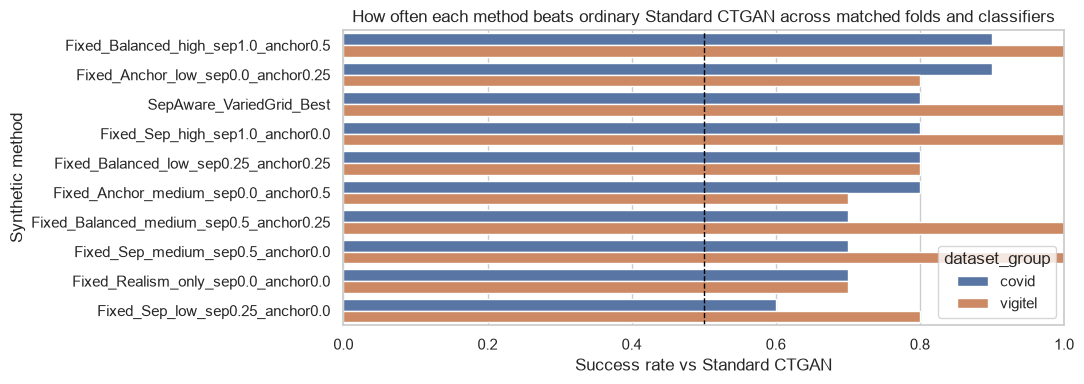

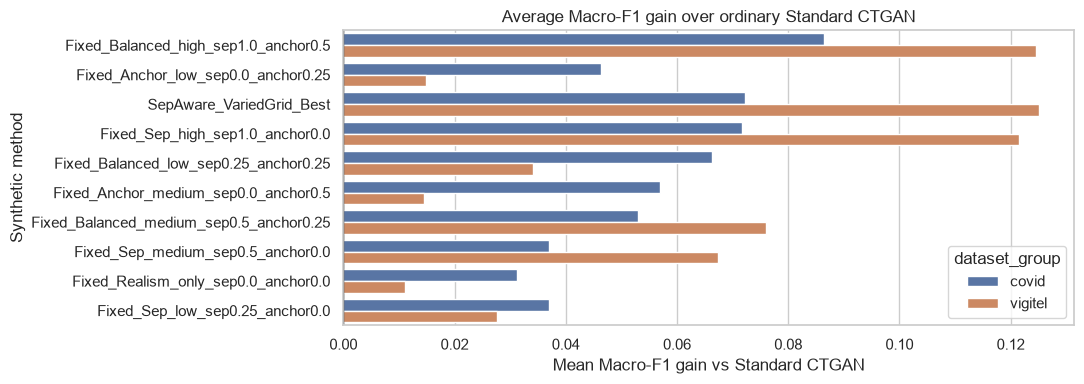

In [14]:
plt.figure(figsize=(11, max(4, 0.35 * success_summary['dataset'].nunique())))
sns.barplot(data=success_summary, y='dataset', x='success_rate_vs_standard_ctgan', hue='dataset_group')
plt.axvline(0.5, color='black', linewidth=1, linestyle='--', label='50% win threshold')
plt.xlim(0, 1)
plt.xlabel('Success rate vs Standard CTGAN')
plt.ylabel('Synthetic method')
plt.title('How often each method beats ordinary Standard CTGAN across matched folds and classifiers')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'success_rate_vs_standard_ctgan.png', dpi=200)
plt.show()

plt.figure(figsize=(11, max(4, 0.35 * success_summary['dataset'].nunique())))
sns.barplot(data=success_summary, y='dataset', x='mean_gain_vs_standard_ctgan', hue='dataset_group')
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Mean Macro-F1 gain vs Standard CTGAN')
plt.ylabel('Synthetic method')
plt.title('Average Macro-F1 gain over ordinary Standard CTGAN')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'mean_macro_f1_gain_vs_standard_ctgan.png', dpi=200)
plt.show()

### How to interpret the success-rate table

Use the following language:

> Standard CTGAN was evaluated under the same 5-fold protocol as SepAware. For every fold and classifier, we compared the Macro-F1 of each SepAware-selected synthetic dataset against the Macro-F1 of the ordinary Standard CTGAN synthetic dataset. The success rate is the proportion of matched fold-classifier comparisons where SepAware was better.

This gives two complementary claims:

1. **Success rate** answers: how consistently did the method beat ordinary CTGAN?
2. **Mean Macro-F1 gain** answers: how large was the average improvement?

If a method has high success rate and positive mean gain, it is consistently better than Standard CTGAN. If it has positive mean gain but lower success rate, it may be strong but unstable.

## 8. Plots

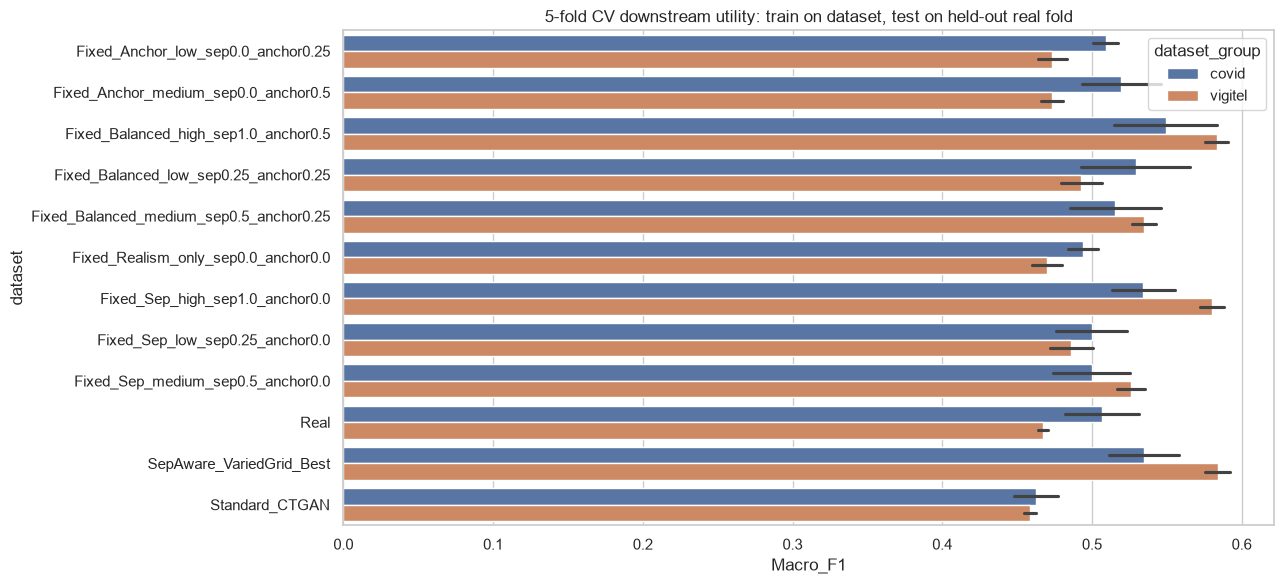

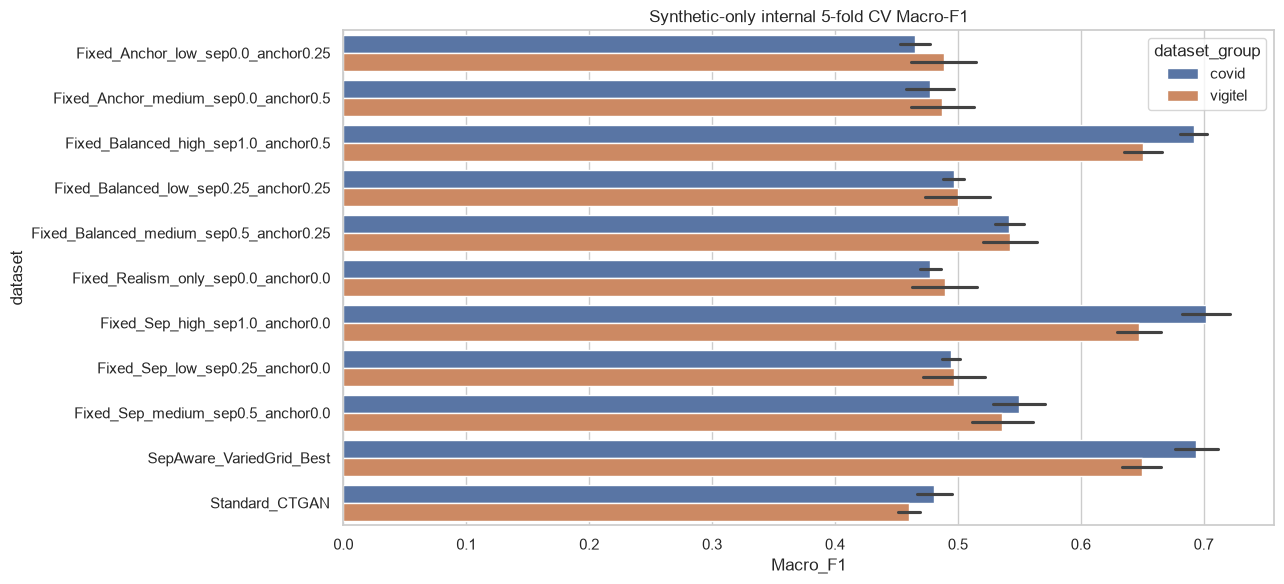

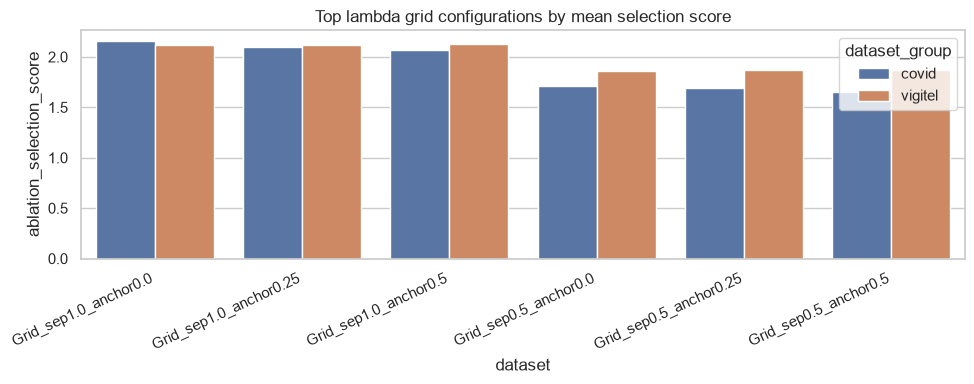

In [15]:
plt.figure(figsize=(13, max(6, 0.35 * transfer_summary["dataset"].nunique())))
plot_df = transfer_fold_mean.copy()
sns.barplot(data=plot_df, y="dataset", x="Macro_F1", hue="dataset_group", errorbar="se")
plt.title("5-fold CV downstream utility: train on dataset, test on held-out real fold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "fixed_lambda_5fold_transfer_macro_f1.png", dpi=200)
plt.show()

plt.figure(figsize=(13, max(6, 0.35 * synthetic_internal_summary["dataset"].nunique())))
sns.barplot(data=synthetic_internal_fold_mean, y="dataset", x="Macro_F1", hue="dataset_group", errorbar="se")
plt.title("Synthetic-only internal 5-fold CV Macro-F1")
plt.tight_layout()
plt.savefig(PLOT_DIR / "fixed_lambda_5fold_synthetic_internal_macro_f1.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 4))
top_grid = grid_summary.groupby("dataset_group").head(6)
sns.barplot(data=top_grid, x="dataset", y="ablation_selection_score", hue="dataset_group")
plt.xticks(rotation=25, ha="right")
plt.title("Top lambda grid configurations by mean selection score")
plt.tight_layout()
plt.savefig(PLOT_DIR / "fixed_lambda_5fold_top_lambda_grid_scores.png", dpi=200)
plt.show()

## 9. Interpretation Template

In [16]:
def auto_interpret():
    lines = []
    for dg, g in transfer_summary.groupby("dataset_group"):
        lines.append(f"### {dg.upper()}")
        top = g.sort_values("Macro_F1_mean", ascending=False).head(5)
        lines.append("Top transfer Macro-F1 datasets:")
        for _, row in top.iterrows():
            lines.append(f"- {row['dataset']}: {row['Macro_F1_mean']:.4f} ± {row['Macro_F1_ci95']:.4f} CI95")
        real = g.loc[g["dataset"] == "Real", "Macro_F1_mean"]
        std = g.loc[g["dataset"] == "Standard_CTGAN", "Macro_F1_mean"]
        sep = g.loc[g["dataset"] == "SepAware_VariedGrid_Best", "Macro_F1_mean"]
        fixed_best = g[g["dataset"].str.startswith("Fixed_", na=False)].sort_values("Macro_F1_mean", ascending=False).head(1)
        if len(real) and len(sep):
            lines.append(f"SepAware_VariedGrid_Best vs Real: {float(sep.iloc[0]) - float(real.iloc[0]):+.4f}")
        if len(std) and len(sep):
            lines.append(f"SepAware_VariedGrid_Best vs Standard_CTGAN: {float(sep.iloc[0]) - float(std.iloc[0]):+.4f}")
        if not fixed_best.empty and len(real):
            fb = fixed_best.iloc[0]
            lines.append(f"Best fixed config is {fb['dataset']} with gain over Real: {fb['Macro_F1_mean'] - float(real.iloc[0]):+.4f}")
        lines.append("")
    text = "\n".join(lines)
    print(text)
    (TABLE_DIR / "automatic_interpretation_fixed_lambda_5fold_cv.txt").write_text(text)

auto_interpret()

### COVID
Top transfer Macro-F1 datasets:
- Fixed_Balanced_high_sep1.0_anchor0.5: 0.5492 ± 0.0959 CI95
- SepAware_VariedGrid_Best: 0.5350 ± 0.0649 CI95
- Fixed_Sep_high_sep1.0_anchor0.0: 0.5343 ± 0.0582 CI95
- Fixed_Balanced_low_sep0.25_anchor0.25: 0.5291 ± 0.1019 CI95
- Fixed_Anchor_medium_sep0.0_anchor0.5: 0.5197 ± 0.0738 CI95
SepAware_VariedGrid_Best vs Real: +0.0281
SepAware_VariedGrid_Best vs Standard_CTGAN: +0.0722
Best fixed config is Fixed_Balanced_high_sep1.0_anchor0.5 with gain over Real: +0.0423

### VIGITEL
Top transfer Macro-F1 datasets:
- SepAware_VariedGrid_Best: 0.5839 ± 0.0225 CI95
- Fixed_Balanced_high_sep1.0_anchor0.5: 0.5834 ± 0.0216 CI95
- Fixed_Sep_high_sep1.0_anchor0.0: 0.5803 ± 0.0228 CI95
- Fixed_Balanced_medium_sep0.5_anchor0.25: 0.5347 ± 0.0226 CI95
- Fixed_Sep_medium_sep0.5_anchor0.0: 0.5261 ± 0.0259 CI95
SepAware_VariedGrid_Best vs Real: +0.1167
SepAware_VariedGrid_Best vs Standard_CTGAN: +0.1251
Best fixed config is Fixed_Balanced_high_sep1.0_anchor0.5 wit

## 10. How This Differs From the Old Notebook

The old fixed-lambda notebooks used one split:

```python
train_test_split(..., test_size=0.25, stratify=y, random_state=42)
```

This notebook uses:

```python
StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
```

The change is applied in two places:

1. **CTGAN training and synthetic generation**
   - Old: CTGAN trained once.
   - New: CTGAN trained separately in each real training fold.

2. **Classification**
   - Old: one held-out real test set.
   - New: five held-out real test folds.
   - Synthetic-only evaluation also uses internal 5-fold CV.

This makes the result more stable and defensible, but absolute Macro-F1 can be lower than the old one-split headline.